# Modulo 2: Deteccion y Tracking de Personas con YOLO

Este cuaderno toma una muestra aleatoria del 15% del manifest y genera los tracks limpios para el resto del pipeline.


## Librerias y parametros de tracking


In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ultralytics import YOLO

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

VIDEO_MANIFEST_PATH = PROJECT_ROOT / "outputs" / "module1" / "video_manifest.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "tracking"
SAMPLED_MANIFEST_PATH = OUTPUT_DIR / "video_manifest_tracking_15pct.csv"
YOLO_MODEL_PATH = PROJECT_ROOT / "yolo11n.pt"

TRACKING_SAMPLE_RATIO = 0.15
RANDOM_SEED = 21
PERSON_CLASS_ID = 0
TRACKER_NAME = "botsort.yaml"
CONF_THRESHOLD = 0.25
IOU_THRESHOLD = 0.50
PERSIST_TRACKS = True
SAVE_PREVIEW = True
MIN_TRACK_LENGTH_FRAMES = 5
DEVICE = None
VERBOSE = False

pd.Series(
    {
        "VIDEO_MANIFEST_PATH": str(VIDEO_MANIFEST_PATH),
        "SAMPLED_MANIFEST_PATH": str(SAMPLED_MANIFEST_PATH),
        "YOLO_MODEL_PATH": str(YOLO_MODEL_PATH),
        "TRACKING_SAMPLE_RATIO": TRACKING_SAMPLE_RATIO,
        "RANDOM_SEED": RANDOM_SEED,
        "PERSON_CLASS_ID": PERSON_CLASS_ID,
        "TRACKER_NAME": TRACKER_NAME,
        "CONF_THRESHOLD": CONF_THRESHOLD,
        "IOU_THRESHOLD": IOU_THRESHOLD,
        "PERSIST_TRACKS": PERSIST_TRACKS,
        "SAVE_PREVIEW": SAVE_PREVIEW,
        "MIN_TRACK_LENGTH_FRAMES": MIN_TRACK_LENGTH_FRAMES,
        "DEVICE": DEVICE,
        "VERBOSE": VERBOSE,
    }
)


VIDEO_MANIFEST_PATH        c:\Users\franco\Downloads\1-INTELIGENCIA_ARTIF...
SAMPLED_MANIFEST_PATH      c:\Users\franco\Downloads\1-INTELIGENCIA_ARTIF...
YOLO_MODEL_PATH            c:\Users\franco\Downloads\1-INTELIGENCIA_ARTIF...
TRACKING_SAMPLE_RATIO                                                   0.15
RANDOM_SEED                                                               21
PERSON_CLASS_ID                                                            0
TRACKER_NAME                                                    botsort.yaml
CONF_THRESHOLD                                                          0.25
IOU_THRESHOLD                                                            0.5
PERSIST_TRACKS                                                          True
SAVE_PREVIEW                                                            True
MIN_TRACK_LENGTH_FRAMES                                                    5
DEVICE                                                                  None

## Manifest original y muestra para tracking


In [2]:
video_manifest_df = pd.read_csv(VIDEO_MANIFEST_PATH)
video_manifest_df = video_manifest_df.sort_values(["split", "class_name", "video_id"]).reset_index(drop=True)

sampled_parts = []

for (split_name, class_name), group_df in video_manifest_df.groupby(["split", "class_name"]):
    sample_size = max(1, int(np.ceil(len(group_df) * TRACKING_SAMPLE_RATIO)))
    sampled_group_df = group_df.sample(n=sample_size, random_state=RANDOM_SEED).copy()
    sampled_parts.append(sampled_group_df)

sampled_video_manifest_df = pd.concat(sampled_parts, ignore_index=True)
sampled_video_manifest_df = sampled_video_manifest_df.sort_values(["split", "class_name", "video_id"]).reset_index(drop=True)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sampled_video_manifest_df.to_csv(SAMPLED_MANIFEST_PATH, index=False)

print(f"Videos en el manifest original: {len(video_manifest_df)}")
print(f"Videos en la muestra para tracking: {len(sampled_video_manifest_df)}")
print(SAMPLED_MANIFEST_PATH)

display(sampled_video_manifest_df.head())


Videos en el manifest original: 328
Videos en la muestra para tracking: 51
c:\Users\franco\Downloads\1-INTELIGENCIA_ARTIFICIAL\PROJECT\ENTREGA_2\outputs\tracking\video_manifest_tracking_15pct.csv


,split,class_name,video_path,video_id,fps_original,frame_count,duration_seconds,width,height
0,test,hurto_simulado,data/test/hurto_simulado/shop_lifter_46.mp4,test__hurto_simulado__shop_lifter_46,24.75,322,13.010101,704,576
1,test,hurto_simulado,data/test/hurto_simulado/shop_lifter_80.mp4,test__hurto_simulado__shop_lifter_80,24.75,223,9.010101,704,576
2,test,hurto_simulado,data/test/hurto_simulado/shop_lifter_95.mp4,test__hurto_simulado__shop_lifter_95,25.00,400,16.000000,704,576
3,test,normal,data/test/normal/shop_lifter_n_0_1.mp4,test__normal__shop_lifter_n_0_1,25.00,450,18.000000,704,576
4,test,normal,data/test/normal/shop_lifter_n_10.mp4,test__normal__shop_lifter_n_10,25.00,475,19.000000,704,576


## Distribucion de la muestra


In [3]:
processing_plan_df = (
    sampled_video_manifest_df.groupby(["split", "class_name"])
    .size()
    .reset_index(name="num_videos")
    .sort_values(["split", "class_name"])
    .reset_index(drop=True)
)
processing_plan_df


,split,class_name,num_videos
0,test,hurto_simulado,3
1,test,normal,5
2,train,hurto_simulado,12
3,train,normal,23
4,val,hurto_simulado,3
5,val,normal,5


## Peso base de YOLO

Si `yolo11n.pt` ya existe en la raiz del proyecto se reutiliza. Si no existe, se descarga y se guarda en esa ruta antes de cargar el modelo.


In [4]:
from ultralytics.utils.downloads import attempt_download_asset

if YOLO_MODEL_PATH.exists():
    print(f"Peso local encontrado: {YOLO_MODEL_PATH}")
else:
    print(f"No existe {YOLO_MODEL_PATH}. Se descargara el peso base yolo11n.pt desde Ultralytics.")
    attempt_download_asset(str(YOLO_MODEL_PATH), release="latest")
    if not YOLO_MODEL_PATH.exists():
        raise FileNotFoundError(f"No fue posible descargar el peso base en {YOLO_MODEL_PATH}")

model = YOLO(str(YOLO_MODEL_PATH))
model


YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_

In [ ]:
model.names

## Ejecucion del tracking sobre la muestra


In [5]:
RAW_TRACK_COLUMNS = [
    "split", "class_name", "video_id", "video_path", "frame_idx", "timestamp_sec",
    "track_id", "class_id", "confidence", "x1", "y1", "x2", "y2",
    "bbox_width", "bbox_height", "center_x", "center_y",
]

SUMMARY_COLUMNS = [
    "split", "class_name", "video_id", "track_id", "start_frame", "end_frame",
    "start_sec", "end_sec", "duration_sec", "num_detections", "mean_confidence",
    "mean_bbox_width", "mean_bbox_height",
]

if TRACKER_NAME in {"botsort", "bytetrack"}:
    TRACKER_NAME = f"{TRACKER_NAME}.yaml"

all_raw_parts = []
all_clean_parts = []

for _, video_row in sampled_video_manifest_df.iterrows():
    split = str(video_row["split"])
    class_name = str(video_row["class_name"])
    video_id = str(video_row["video_id"])
    video_path = Path(video_row["video_path"])
    video_source_path = PROJECT_ROOT / video_path
    fps = float(video_row["fps_original"])
    video_output_dir = OUTPUT_DIR / split / video_id
    preview_path = video_output_dir / "tracking_preview.mp4"

    print(f"Procesando: {video_id}")

    track_kwargs = {
        "source": str(video_source_path),
        "stream": True,
        "persist": PERSIST_TRACKS,
        "tracker": TRACKER_NAME,
        "classes": [PERSON_CLASS_ID],
        "conf": CONF_THRESHOLD,
        "iou": IOU_THRESHOLD,
        "verbose": VERBOSE,
    }
    if DEVICE:
        track_kwargs["device"] = DEVICE

    results = model.track(**track_kwargs)
    raw_rows = []
    preview_writer = None

    try:
        for frame_idx, result in enumerate(results):
            if result.boxes is not None and len(result.boxes) > 0 and result.boxes.id is not None:
                boxes = result.boxes
                timestamp_sec = frame_idx / fps

                for detection_idx in range(len(boxes)):
                    class_id = int(boxes.cls[detection_idx].item())
                    if class_id != PERSON_CLASS_ID:
                        continue

                    track_id = int(boxes.id[detection_idx].item())
                    confidence = float(boxes.conf[detection_idx].item())
                    x1, y1, x2, y2 = boxes.xyxy[detection_idx].tolist()
                    bbox_width = x2 - x1
                    bbox_height = y2 - y1
                    center_x = x1 + (bbox_width / 2.0)
                    center_y = y1 + (bbox_height / 2.0)

                    raw_rows.append(
                        {
                            "split": split,
                            "class_name": class_name,
                            "video_id": video_id,
                            "video_path": video_path.as_posix(),
                            "frame_idx": int(frame_idx),
                            "timestamp_sec": round(timestamp_sec, 6),
                            "track_id": int(track_id),
                            "class_id": int(class_id),
                            "confidence": round(confidence, 6),
                            "x1": round(float(x1), 6),
                            "y1": round(float(y1), 6),
                            "x2": round(float(x2), 6),
                            "y2": round(float(y2), 6),
                            "bbox_width": round(float(bbox_width), 6),
                            "bbox_height": round(float(bbox_height), 6),
                            "center_x": round(float(center_x), 6),
                            "center_y": round(float(center_y), 6),
                        }
                    )

            if SAVE_PREVIEW:
                annotated_frame = result.plot()
                if preview_writer is None:
                    frame_height, frame_width = annotated_frame.shape[:2]
                    video_output_dir.mkdir(parents=True, exist_ok=True)
                    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
                    preview_writer = cv2.VideoWriter(str(preview_path), fourcc, fps, (frame_width, frame_height))
                preview_writer.write(annotated_frame)
    finally:
        if preview_writer is not None:
            preview_writer.release()

    raw_df = pd.DataFrame(raw_rows, columns=RAW_TRACK_COLUMNS) if raw_rows else pd.DataFrame(columns=RAW_TRACK_COLUMNS)

    if raw_df.empty:
        clean_df = pd.DataFrame(columns=RAW_TRACK_COLUMNS)
    else:
        valid_mask = (
            raw_df["track_id"].notna()
            & raw_df["x1"].notna()
            & raw_df["y1"].notna()
            & raw_df["x2"].notna()
            & raw_df["y2"].notna()
            & raw_df["bbox_width"].notna()
            & raw_df["bbox_height"].notna()
            & (raw_df["x2"] > raw_df["x1"])
            & (raw_df["y2"] > raw_df["y1"])
            & (raw_df["bbox_width"] > 0)
            & (raw_df["bbox_height"] > 0)
        )
        clean_df = raw_df.loc[valid_mask, RAW_TRACK_COLUMNS].copy()

        track_lengths = (
            clean_df.groupby(["split", "class_name", "video_id", "track_id"])
            .size()
            .reset_index(name="num_detections")
        )
        valid_tracks = track_lengths.loc[
            track_lengths["num_detections"] >= MIN_TRACK_LENGTH_FRAMES,
            ["split", "class_name", "video_id", "track_id"],
        ]
        clean_df = clean_df.merge(valid_tracks, on=["split", "class_name", "video_id", "track_id"], how="inner")
        clean_df = clean_df[RAW_TRACK_COLUMNS].sort_values(["split", "class_name", "video_id", "frame_idx", "track_id"]).reset_index(drop=True)

    if clean_df.empty:
        summary_df = pd.DataFrame(columns=SUMMARY_COLUMNS)
    else:
        summary_df = (
            clean_df.groupby(["split", "class_name", "video_id", "track_id"])
            .agg(
                start_frame=("frame_idx", "min"),
                end_frame=("frame_idx", "max"),
                start_sec=("timestamp_sec", "min"),
                end_sec=("timestamp_sec", "max"),
                num_detections=("frame_idx", "count"),
                mean_confidence=("confidence", "mean"),
                mean_bbox_width=("bbox_width", "mean"),
                mean_bbox_height=("bbox_height", "mean"),
            )
            .reset_index()
        )
        summary_df["duration_sec"] = summary_df["end_sec"] - summary_df["start_sec"]
        for column in ["start_sec", "end_sec", "duration_sec", "mean_confidence", "mean_bbox_width", "mean_bbox_height"]:
            summary_df[column] = summary_df[column].round(6)
        summary_df = summary_df[SUMMARY_COLUMNS].sort_values(["split", "class_name", "video_id", "track_id"]).reset_index(drop=True)

    video_output_dir.mkdir(parents=True, exist_ok=True)
    raw_df.to_csv(video_output_dir / "tracks_raw.csv", index=False)
    clean_df.to_csv(video_output_dir / "tracks_clean.csv", index=False)
    summary_df.to_csv(video_output_dir / "track_summary.csv", index=False)

    all_raw_parts.append(raw_df)
    all_clean_parts.append(clean_df)

all_raw_df = pd.concat(all_raw_parts, ignore_index=True) if all_raw_parts else pd.DataFrame(columns=RAW_TRACK_COLUMNS)
all_clean_df = pd.concat(all_clean_parts, ignore_index=True) if all_clean_parts else pd.DataFrame(columns=RAW_TRACK_COLUMNS)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
all_raw_df.to_csv(OUTPUT_DIR / "all_tracks_raw.csv", index=False)
all_clean_df.to_csv(OUTPUT_DIR / "all_tracks_clean.csv", index=False)

print(SAMPLED_MANIFEST_PATH)
print(OUTPUT_DIR / "all_tracks_raw.csv")
print(OUTPUT_DIR / "all_tracks_clean.csv")
print(f"Filas raw: {len(all_raw_df)}")
print(f"Filas clean: {len(all_clean_df)}")


Procesando: test__hurto_simulado__shop_lifter_46
Procesando: test__hurto_simulado__shop_lifter_80
Procesando: test__hurto_simulado__shop_lifter_95
Procesando: test__normal__shop_lifter_n_0_1
Procesando: test__normal__shop_lifter_n_10
Procesando: test__normal__shop_lifter_n_196
Procesando: test__normal__shop_lifter_n_39
Procesando: train__hurto_simulado__shop_lifter_47
Procesando: train__hurto_simulado__shop_lifter_59
Procesando: train__hurto_simulado__shop_lifter_65
Procesando: train__hurto_simulado__shop_lifter_69
Procesando: train__normal__shop_lifter_n_109
Procesando: train__normal__shop_lifter_n_123
Procesando: train__normal__shop_lifter_n_124
Procesando: train__normal__shop_lifter_n_126
Procesando: train__normal__shop_lifter_n_130
Procesando: train__normal__shop_lifter_n_158
Procesando: train__normal__shop_lifter_n_166
Procesando: train__normal__shop_lifter_n_176
Procesando: train__normal__shop_lifter_n_179
Procesando: train__normal__shop_lifter_n_191
Procesando: train__normal__sh

## Resumen de tracks obtenidos


In [8]:
if all_clean_df.empty:
    pd.DataFrame(columns=["split", "class_name", "num_detections", "num_tracks"])
else:
    summary_df = (
        all_clean_df.groupby(["split", "class_name"])
        .agg(
            num_detections=("frame_idx", "count"),
            num_tracks=("track_id", pd.Series.nunique),
        )
        .reset_index()
        .sort_values(["split", "class_name"])
        .reset_index(drop=True)
    )
    summary_df

## Un preview del seguimiento


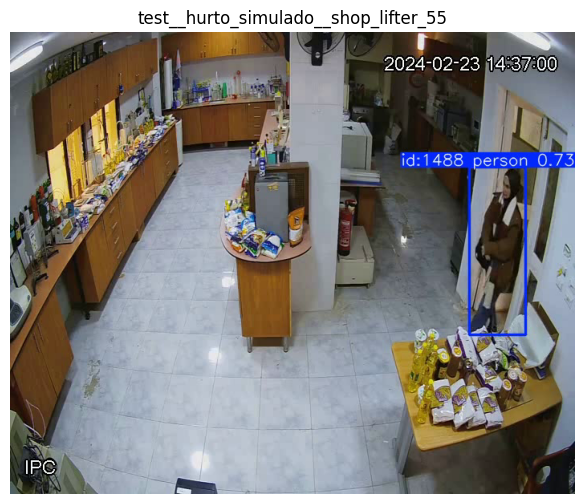

In [23]:
preview_candidates = sorted(OUTPUT_DIR.rglob("tracking_preview.mp4"))

if not preview_candidates:
    print("No hay previews guardados todavía.")
else:
    preview_path = preview_candidates[8]
    capture = cv2.VideoCapture(str(preview_path))
    capture.set(cv2.CAP_PROP_POS_FRAMES, 36)
    ok, frame = capture.read()
    capture.release()

    if ok:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 6))
        plt.imshow(frame_rgb)
        plt.title(preview_path.parent.name)
        plt.axis("off")
        plt.show()
    else:
        print(f"No se pudo leer el preview: {preview_path}")